# Visualizing Genomic Features for Disease Subtype Cluster Analysis
## Case-Based Scenario & Practical Dataset EDA

**Dataset:** `RNA_seq_1.csv` (supplied project dataset)

This notebook completes two requested parts of the project:
1. **Problem Statement → Case-Based Scenario**
2. **Practical implementation of Project Dataset EDA (Program)**

The EDA prepares the dataset for the later PCA, t-SNE, K-Means and Hierarchical Clustering stages described in the project abstract.

## 1. Problem Statement → Case-Based Scenario

### Case: Discovering hidden disease subtypes from patient gene-expression profiles

Imagine a cancer research team has collected gene-expression profiles from many patient samples. Each sample contains hundreds or thousands of gene-expression measurements. The researchers want to discover natural groups of biologically similar samples that may represent different disease subtypes.

The challenge is that genomic data is high-dimensional and contains complex relationships that are difficult to inspect directly. Therefore, the project first explores and prepares the data, then uses dimensionality reduction and clustering to make those patterns understandable.

### Case-based solution

**TCGA gene-expression data → EDA/preparation → PCA → t-SNE → K-Means & Hierarchical Clustering → evaluation**

- **PCA:** summarizes the major directions of variation.
- **t-SNE:** creates a 2D/3D view emphasizing local similarity.
- **K-Means:** discovers groups around cluster centers.
- **Hierarchical Clustering:** shows how samples progressively form groups.

This notebook concentrates on the first stage: understanding the supplied dataset before modeling.

## 2. What the data represents

A gene-expression matrix can be viewed as:

- **Rows:** patient/sample observations
- **Columns:** gene-expression features
- **Cell value:** measured expression level

If two samples have similar patterns across many genes, they may be biologically similar. The clustering stage attempts to discover such patterns without requiring predefined subtype labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("/mnt/data/RNA_seq_1.csv")
data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print(f"Shape: {data.shape[0]:,} samples × {data.shape[1]:,} columns")
display(data.head())

Dataset loaded successfully
Shape: 4,571 samples × 529 columns


,attrib_name,TCGA.02.0001,TCGA.02.0003,TCGA.02.0004,TCGA.02.0007,TCGA.02.0009,TCGA.02.0010,TCGA.02.0011,TCGA.02.0014,TCGA.02.0015,TCGA.02.0016,TCGA.02.0021,TCGA.02.0023,TCGA.02.0024,TCGA.02.0025,TCGA.02.0026,TCGA.02.0027,TCGA.02.0028,TCGA.02.0033,TCGA.02.0034,TCGA.02.0038,TCGA.02.0039,TCGA.02.0043,TCGA.02.0046,TCGA.02.0047,TCGA.02.0048,TCGA.02.0051,TCGA.02.0052,TCGA.02.0054,TCGA.02.0057,TCGA.02.0058,TCGA.02.0059,TCGA.02.0060,TCGA.02.0064,TCGA.02.0068,TCGA.02.0069,TCGA.02.0070,TCGA.02.0071,TCGA.02.0074,TCGA.02.0075,...,TCGA.32.2491,TCGA.32.2494,TCGA.32.2495,TCGA.32.2615,TCGA.32.2616,TCGA.32.2632,TCGA.32.2634,TCGA.32.2638,TCGA.32.4208,TCGA.32.4209,TCGA.32.4210,TCGA.32.4211,TCGA.32.4213,TCGA.32.4719,TCGA.32.5222,TCGA.41.2571,TCGA.41.2572,TCGA.41.2573,TCGA.41.2575,TCGA.41.3392,TCGA.41.3393,TCGA.41.3915,TCGA.41.4097,TCGA.41.5651,TCGA.76.4925,TCGA.76.4926,TCGA.76.4927,TCGA.76.4928,TCGA.76.4929,TCGA.76.4931,TCGA.76.4932,TCGA.76.4934,TCGA.76.4935,TCGA.76.6191,TCGA.76.6192,TCGA.76.6193,TCGA.76.6282,TCGA.76.6285,TCGA.81.5910,TCGA.87.5896
0,AACS,6.5006,6.5392,7.3778,7.1869,7.6750,7.9960,8.3551,6.8401,6.3491,6.2900,8.3978,6.4740,7.4595,5.8355,6.8602,6.9740,6.2721,6.0592,5.5366,7.9439,6.4002,7.0831,6.4934,9.3950,6.8252,6.5144,7.0943,5.8485,7.1611,6.9127,6.2711,7.4394,6.6767,6.3091,6.2631,6.9619,7.0062,7.1464,6.4603,...,7.0151,6.7481,7.3770,7.4249,8.0759,7.4016,7.4872,6.9200,7.6414,6.9602,6.7754,6.3623,6.6239,7.4131,5.9132,7.9154,7.5645,8.3524,7.4707,7.7575,7.1475,6.7003,6.9785,7.2320,6.4158,6.4830,5.7423,6.7010,6.3783,6.2613,5.8965,6.3478,6.1927,7.2218,7.5393,6.9078,7.0076,7.6763,7.1052,7.2302
1,FSTL1,8.7297,9.7944,12.0596,4.9451,10.8401,8.9316,4.2406,7.7385,10.7565,9.6489,8.7639,9.3122,11.6597,11.0235,8.9330,9.8302,9.0426,9.4436,7.6643,4.8065,10.1640,11.7282,8.9947,3.6624,9.1332,9.8877,10.7869,8.1117,10.2272,7.0917,10.2257,10.9176,11.0029,11.4481,10.0542,10.4911,10.8357,9.7812,10.2660,...,10.6250,10.9468,9.4586,10.3486,10.1780,10.7518,10.5432,10.7401,9.3812,9.9768,9.0513,10.8269,10.8218,10.5590,8.4571,9.0795,10.6261,9.2781,9.0223,10.1369,9.7595,11.1175,10.7493,9.2150,8.9810,9.2751,8.7490,9.6543,8.6958,10.7068,8.1148,8.8745,9.9205,10.1363,9.8328,11.0918,10.7895,9.6826,9.8474,10.4376
2,ELMO2,5.5114,6.2140,7.0517,5.2304,6.6207,7.5524,6.7073,7.2623,7.1187,7.9180,6.8197,6.7753,6.5072,6.1397,7.5017,6.6886,5.9621,5.0475,5.0339,5.7763,6.8546,6.6321,5.2627,5.4078,7.3421,5.6798,6.4928,5.2923,6.4961,5.0926,6.0133,6.4625,7.1523,7.7415,7.1398,6.5910,7.5239,7.6113,6.9720,...,7.7316,6.9294,7.9882,7.0988,7.3856,7.9220,8.0931,8.1476,6.8317,7.7929,7.3753,7.2524,6.8696,7.8527,6.1729,8.1829,7.8302,8.2224,7.2680,7.7922,7.7017,6.8313,7.4145,8.4453,7.6833,6.6767,7.0169,6.5213,6.7242,7.1421,7.3827,6.8193,6.6757,7.7135,7.6458,7.8877,7.5698,7.0198,7.5335,7.9569
3,CREB3L1,4.8830,4.8363,6.1124,5.8186,5.3332,6.0873,4.8655,4.5245,4.8251,4.8311,5.8496,5.1456,4.5637,5.2698,4.2310,5.0045,4.9075,4.9791,5.8349,4.5663,4.8769,5.3871,4.8966,8.1200,4.9850,5.4895,5.0283,4.8649,5.0767,5.6547,4.6809,5.5850,4.7116,4.5656,4.5762,4.5346,4.2366,4.1220,4.4084,...,4.4609,4.3547,4.2821,4.5281,4.2188,5.8610,4.3215,4.8117,4.4600,4.9042,4.2122,4.3146,4.8735,4.4990,5.4366,4.6958,4.8747,4.4381,4.8869,4.6922,4.8316,4.4055,4.4830,4.6351,4.4378,4.6157,5.3991,4.8597,4.7336,4.4804,4.6810,5.6369,5.3315,5.0622,5.5533,4.6878,5.3670,4.6857,6.1549,6.8131
4,RPS11,10.9848,10.8112,10.4364,10.4773,10.6373,11.0015,10.6859,10.6613,10.2849,10.2522,10.3500,10.3595,10.5171,10.3298,10.1398,10.6741,10.5937,10.8811,10.3388,10.4947,10.1749,10.2888,10.9456,10.7006,10.2884,10.4748,10.7287,10.9648,10.5731,11.3426,10.5084,10.4709,10.6624,10.3397,10.6621,10.3802,10.6819,10.6266,10.3734,...,10.4477,10.5094,10.9466,11.5647,11.1990,11.1337,10.9711,11.4233,11.0010,10.7519,10.6509,10.6666,10.6041,10.6675,10.8368,11.1919,10.9741,10.9342,11.1522,11.2145,10.9388,11.0477,10.6296,10.5761,10.9364,10.8703,11.0485,11.0020,11.0760,10.3866,10.9302,10.4001,10.3514,10.6369,10.5655,10.4751,10.5730,10.4392,10.6853,10.3156


## 3. Dataset dimensions

The first check is the number of observations and variables. A large number of gene-expression columns is expected in genomic data and is one of the main reasons dimensionality reduction is useful later.

In [2]:
print("Rows (samples):", f"{data.shape[0]:,}")
print("Columns:", f"{data.shape[1]:,}")

Rows (samples): 4,571
Columns: 529


## 4. Data types and feature identification

Gene-expression values should be numeric for mathematical modeling. Any identifier column is retained for interpretation but excluded from numerical calculations.

In [3]:
numeric_features = data.select_dtypes(include=np.number).columns.tolist()
non_numeric = data.select_dtypes(exclude=np.number).columns.tolist()
print(f"Numeric expression features: {len(numeric_features):,}")
print(f"Non-numeric columns: {len(non_numeric):,}")
if non_numeric: print(non_numeric)
print("\nData type counts:")
display(data.dtypes.value_counts())

Numeric expression features: 528
Non-numeric columns: 1
['attrib_name']

Data type counts:


float64    528
object       1
Name: count, dtype: int64

## 5. Missing-value analysis

Missing values can interfere with PCA and distance-based clustering. We first quantify them instead of making assumptions about how they should be handled.

In [4]:
missing = data.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing.sum()))
print("Columns containing missing values:", int((missing > 0).sum()))
missing_summary = pd.DataFrame({"Missing Values": missing, "Missing %": (missing/len(data)*100).round(3)})
display(missing_summary.head(20))

Total missing values: 191
Columns containing missing values: 191


,Missing Values,Missing %
TCGA.19.5950,1,0.022
TCGA.19.5947,1,0.022
TCGA.19.4068,1,0.022
TCGA.19.2631,1,0.022
TCGA.19.2629,1,0.022
TCGA.19.2625,1,0.022
TCGA.19.2624,1,0.022
TCGA.19.2623,1,0.022
TCGA.19.2621,1,0.022
TCGA.19.2620,1,0.022


## 6. Duplicate samples

Exact duplicate rows can distort clustering because the same profile would receive repeated weight.

In [5]:
duplicates = int(data.duplicated().sum())
print("Duplicate rows:", duplicates)
print("Duplicate percentage:", round(duplicates/len(data)*100, 3), "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


## 7. Descriptive statistics

We inspect mean, standard deviation, quartiles, minimum and maximum values. These help us understand the scale and spread of gene-expression measurements.

In [6]:
stats = data[numeric_features].describe().T
stats["variance"] = data[numeric_features].var()
stats["missing"] = data[numeric_features].isna().sum()
display(stats.head(20))

,count,mean,std,min,25%,50%,75%,max,variance,missing
TCGA.02.0001,4571.0,5.984879,1.728516,3.2320,4.65060,5.5531,6.90415,13.5752,2.987768,0
TCGA.02.0003,4571.0,6.138479,1.879417,3.2197,4.58140,5.7330,7.30525,13.3016,3.532209,0
TCGA.02.0004,4571.0,6.366215,2.082473,3.2564,4.48510,6.0541,7.80285,13.5763,4.336694,0
TCGA.02.0007,4571.0,6.094556,1.939755,3.0903,4.56850,5.5140,7.23315,13.5564,3.762648,0
TCGA.02.0009,4571.0,6.228164,1.941639,2.7953,4.58235,5.8515,7.49060,13.4381,3.769961,0
TCGA.02.0010,4571.0,6.110623,1.879027,3.2402,4.59410,5.6374,7.20440,13.5231,3.530741,0
TCGA.02.0011,4571.0,6.185587,2.021023,3.0119,4.45950,5.6777,7.56245,13.6683,4.084533,0
TCGA.02.0014,4571.0,6.235158,2.027263,3.3839,4.45230,5.7684,7.62235,13.7901,4.109794,0
TCGA.02.0015,4571.0,6.256211,2.035121,3.3440,4.47240,5.8744,7.60120,13.4971,4.141716,0
TCGA.02.0016,4571.0,6.247381,1.980385,3.2928,4.47315,5.9302,7.59845,13.3710,3.921923,0


## 8. Expression distributions

A histogram shows how expression values are distributed. Because hundreds of genes cannot be displayed clearly at once, we visualize a representative subset.

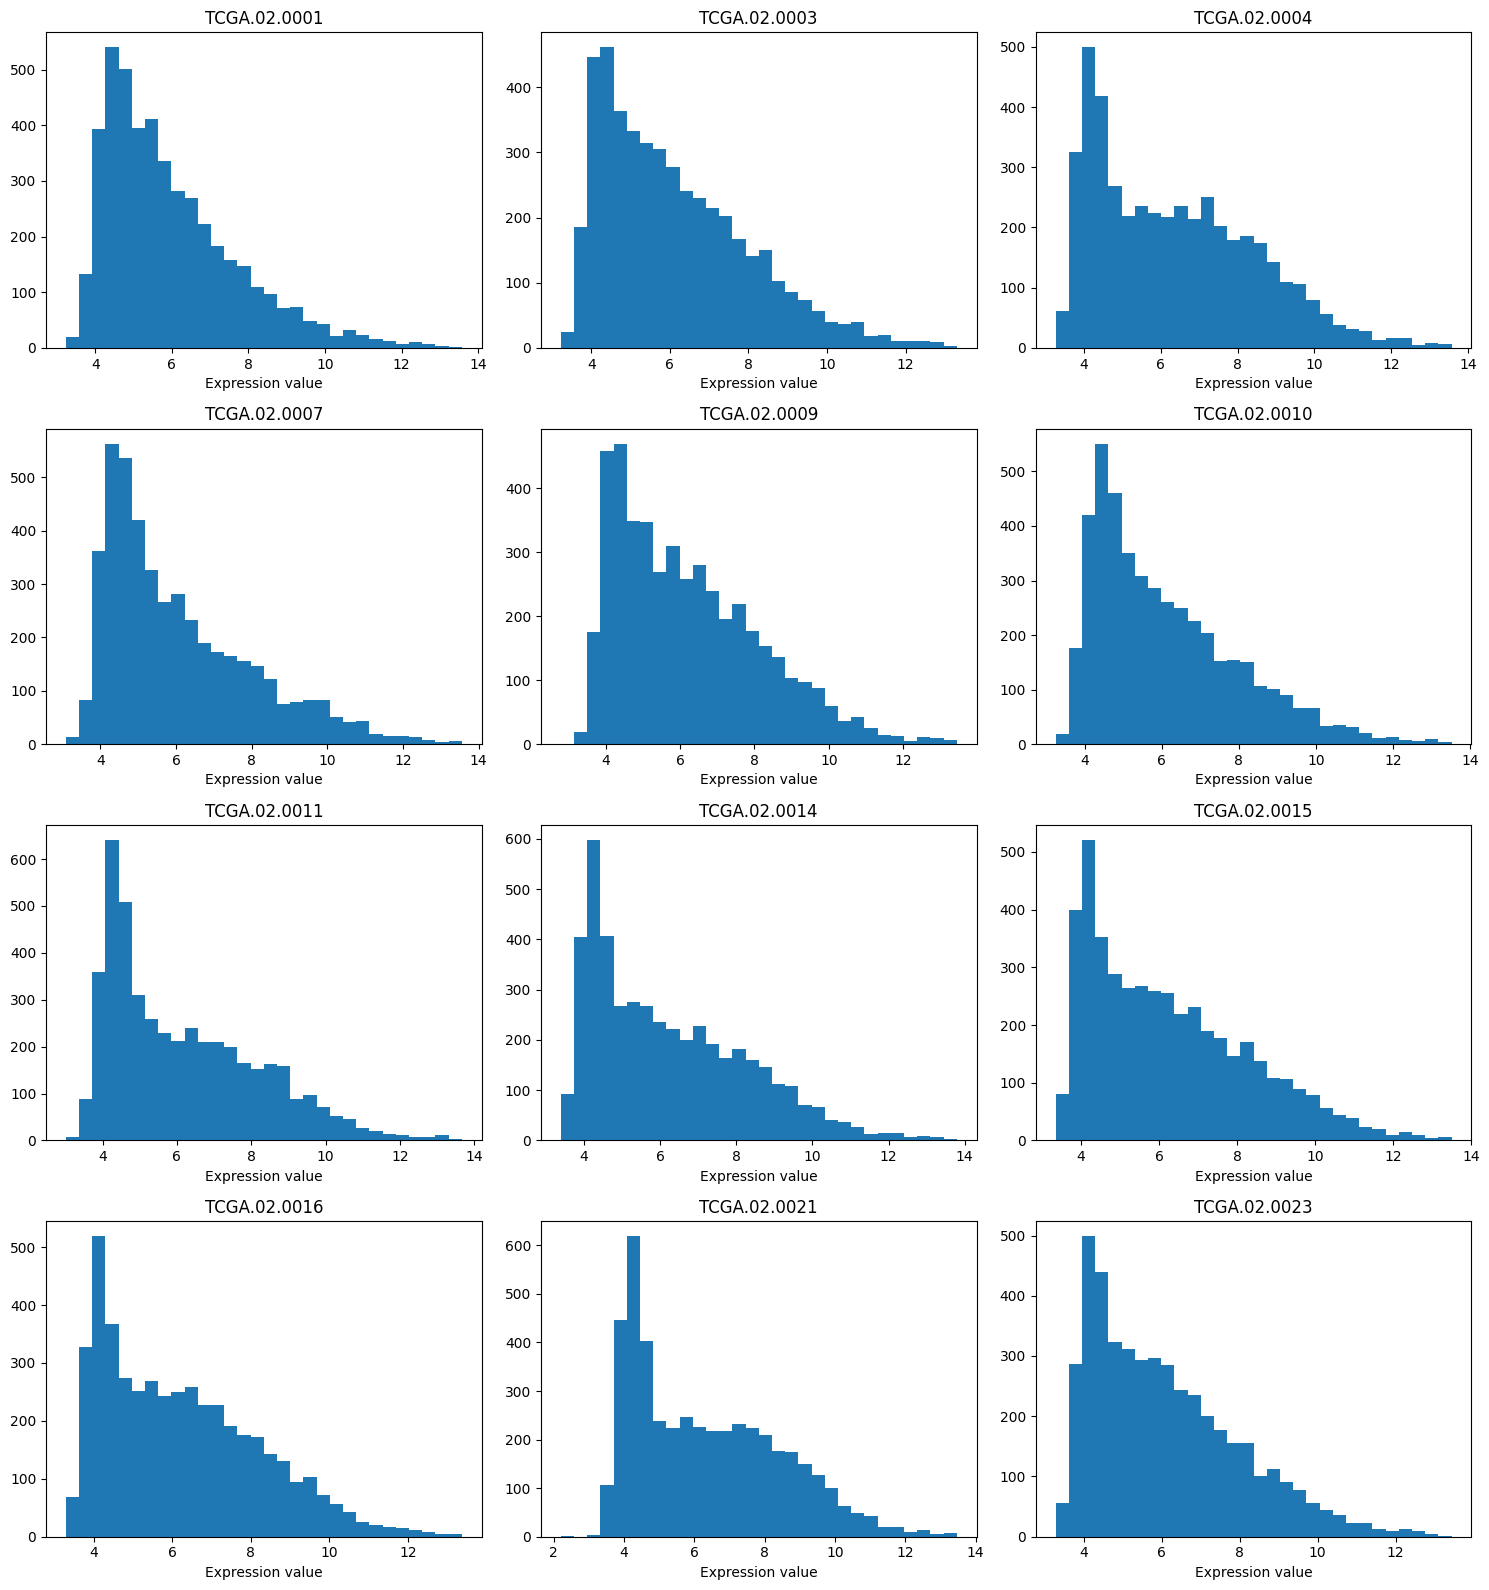

In [7]:
sample_features = numeric_features[:min(12, len(numeric_features))]
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.ravel()
for ax, col in zip(axes, sample_features):
    axes_data = data[col].dropna().to_numpy()
    ax.hist(axes_data, bins=30)
    ax.set_title(str(col))
    ax.set_xlabel("Expression value")
for ax in axes[len(sample_features):]: ax.remove()
plt.tight_layout(); plt.show()

## 9. Boxplots and possible outliers

Boxplots show the median, spread and potential extreme values. In biological data, an extreme value is not automatically an error, so EDA identifies it rather than blindly deleting it.

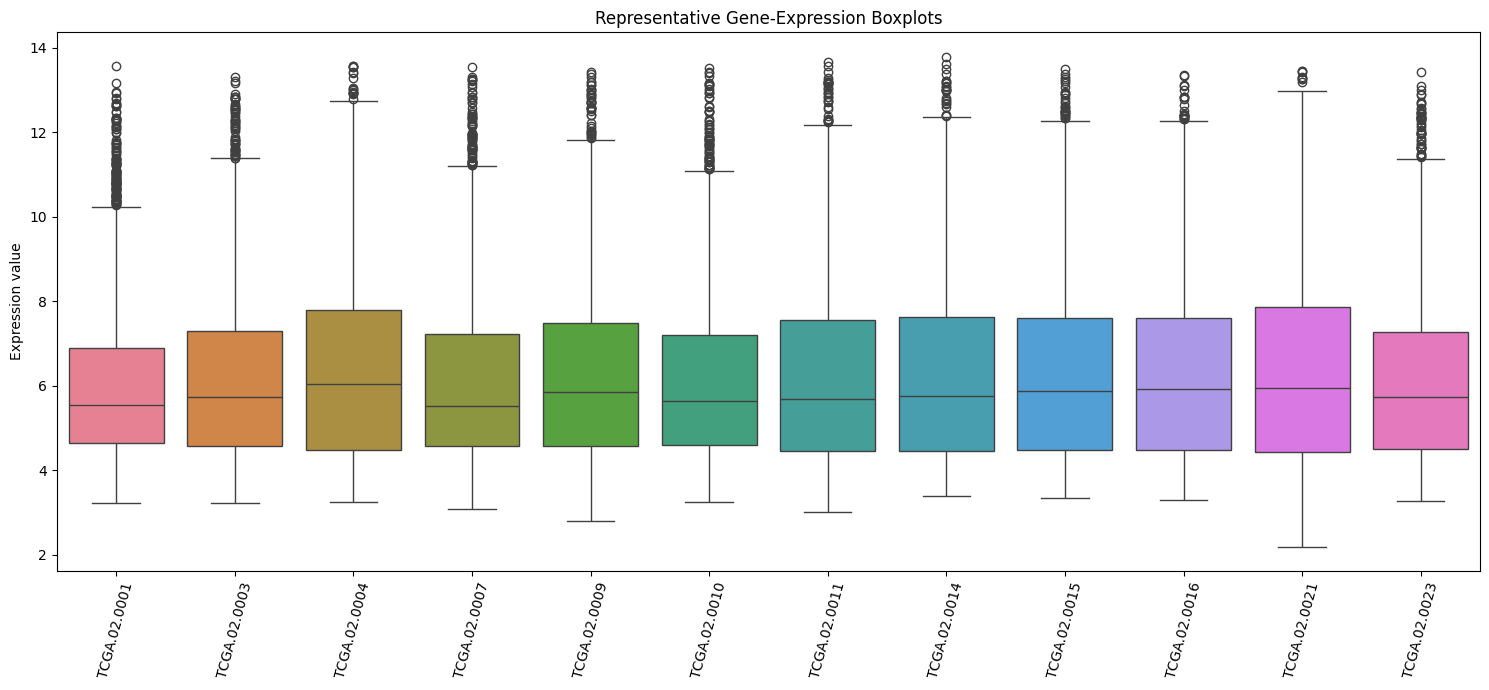

In [8]:
plt.figure(figsize=(15,7))
sns.boxplot(data=data[sample_features])
plt.xticks(rotation=75)
plt.ylabel("Expression value")
plt.title("Representative Gene-Expression Boxplots")
plt.tight_layout(); plt.show()

## 10. Feature variance

Variance measures how much a feature changes across samples. Very low-variance genes provide little separation information, while high-variance genes may capture differences between samples.

This is an exploratory check, not a claim that high variance automatically means biological importance.

,Variance
TCGA.28.6450,4.716547
TCGA.12.3653,4.716200
TCGA.06.5859,4.663261
TCGA.87.5896,4.647325
TCGA.19.5960,4.638390
TCGA.76.6285,4.632641
TCGA.06.5858,4.626916
TCGA.19.2629,4.606965
TCGA.19.5952,4.603570
TCGA.02.0116,4.588271


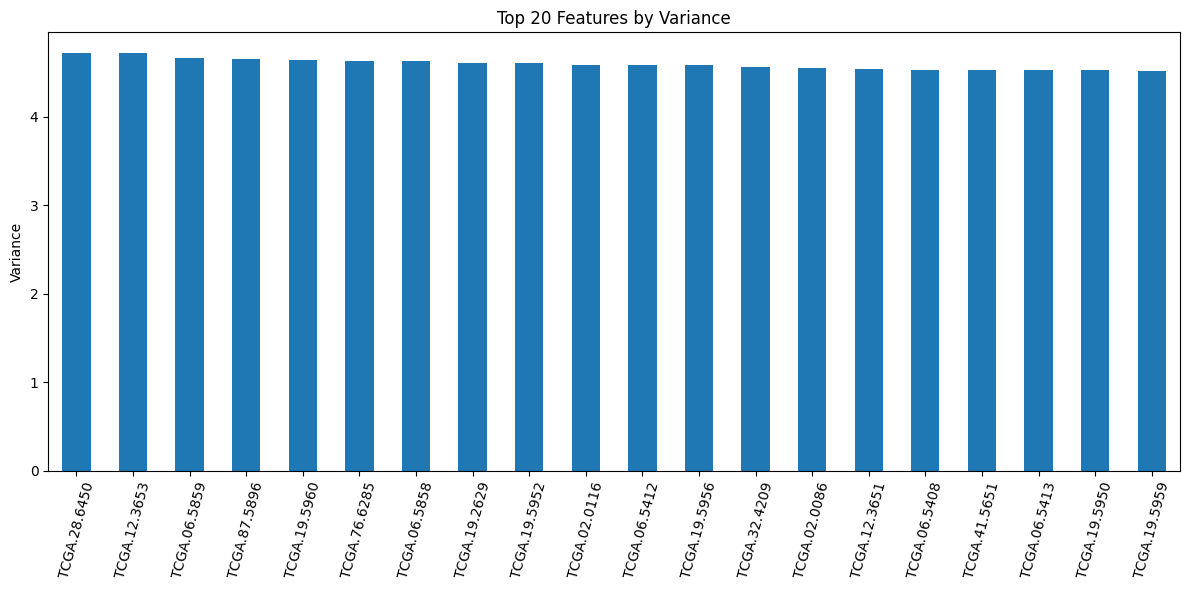

In [9]:
feature_variance = data[numeric_features].var().sort_values(ascending=False)
display(feature_variance.head(20).to_frame("Variance"))
plt.figure(figsize=(12,6))
feature_variance.head(20).plot(kind="bar")
plt.title("Top 20 Features by Variance")
plt.ylabel("Variance")
plt.xticks(rotation=75)
plt.tight_layout(); plt.show()

## 11. Low-variance feature check

This checks how many numerical features have extremely small variance. The threshold is only an EDA diagnostic and is not a universal biological cutoff.

In [10]:
threshold = 1e-5
low_var = int((feature_variance <= threshold).sum())
print(f"Features with variance <= {threshold}: {low_var:,}")
print(f"Percentage of numeric features: {low_var/len(numeric_features)*100:.2f}%")

Features with variance <= 1e-05: 0
Percentage of numeric features: 0.00%


## 12. Correlation analysis

Gene features can be correlated. A full correlation matrix for hundreds of features would be difficult to read, so we inspect a representative subset. Correlation ranges from -1 to +1.

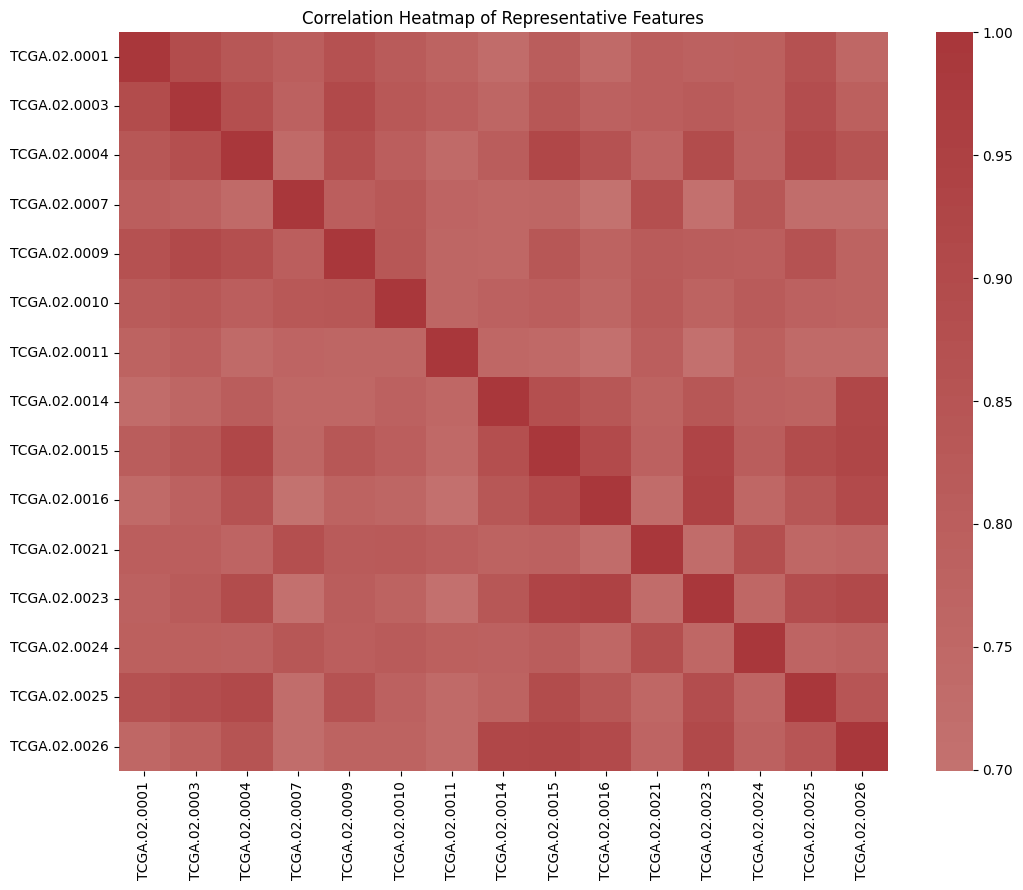

In [11]:
corr_features = numeric_features[:min(15, len(numeric_features))]
plt.figure(figsize=(11,9))
sns.heatmap(data[corr_features].corr(), cmap="vlag", center=0)
plt.title("Correlation Heatmap of Representative Features")
plt.tight_layout(); plt.show()

## 13. Sample-wise variability

We calculate the standard deviation across the expression features for each sample. This helps identify whether some samples have unusually different overall variability.

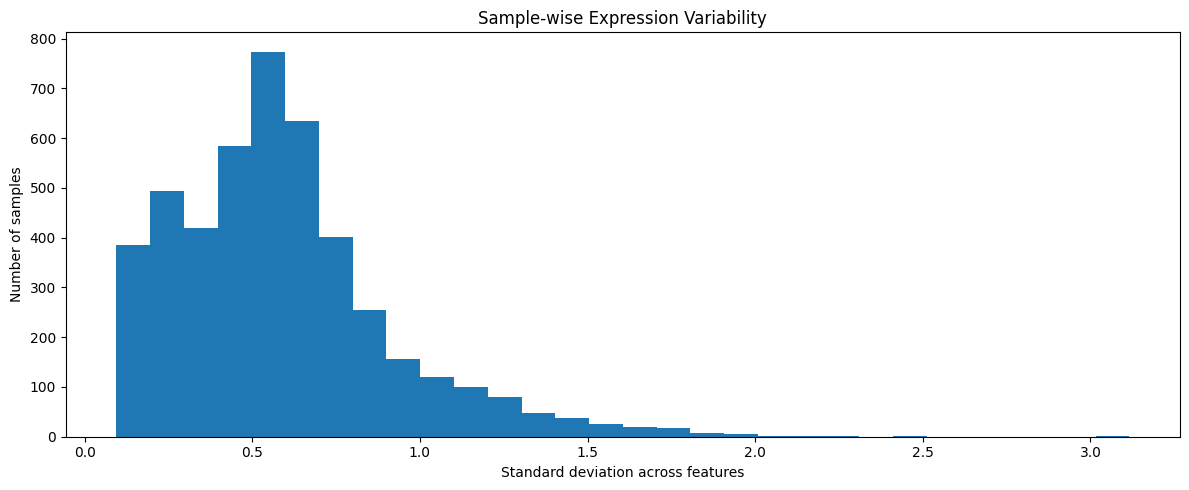

,Sample SD
count,4571.000000
mean,0.588761
std,0.324953
min,0.094469
25%,0.365876
50%,0.549507
75%,0.727486
max,3.116066


In [12]:
sample_std = data[numeric_features].std(axis=1)
plt.figure(figsize=(12,5))
plt.hist(sample_std.dropna().to_numpy(), bins=30)
plt.title("Sample-wise Expression Variability")
plt.xlabel("Standard deviation across features")
plt.ylabel("Number of samples")
plt.tight_layout(); plt.show()
display(sample_std.describe().to_frame("Sample SD"))

## 14. EDA findings and connection to the ML pipeline

### What EDA gives us

1. Dataset size and structure
2. Numeric genomic feature identification
3. Missing-value status
4. Duplicate-row status
5. Expression distributions
6. Possible extreme values
7. Feature variability
8. Representative feature correlations

### Why this matters

The next modeling stage can now take the numerical expression matrix through:

**standardization → PCA → t-SNE → K-Means → Hierarchical Clustering → evaluation**

EDA is therefore the evidence-based foundation of the project rather than a separate activity.

## 15. Viva-ready explanation

**Problem:** A cancer research team has many gene-expression measurements per patient and wants to discover naturally occurring groups that may correspond to disease subtypes.

**Difficulty:** Thousands of features make the data high-dimensional and hard to visualize directly.

**EDA:** We inspect structure, missing values, duplicates, distributions, variability and correlations before modeling.

**Next step:** PCA compresses major variation, t-SNE provides an interpretable visual map, and K-Means/Hierarchical Clustering discover groups.

> **One-line summary:** We first understand and prepare the genomic data, then transform it into an understandable representation from which possible patient subgroups can be discovered.

## 16. Key definitions

- **EDA:** Exploratory Data Analysis — examining data before modeling.
- **Feature:** A variable used to describe an observation; here, a gene-expression measurement.
- **Sample:** One patient/biological observation.
- **Variance:** How much values differ from their mean.
- **Correlation:** How two variables change in relation to one another.
- **Outlier:** An unusually extreme observation.
- **High-dimensional data:** Data with many features.
- **Dimensionality reduction:** Reducing the number of features while retaining important information.